In [ ]:
import sys
sys.path.append("../")
import importlib

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *

In [3]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cpu"
}

# Data

In [4]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [5]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6547  val_acc=0.737
[002/10] train_loss=0.5763  val_acc=0.737
[003/10] train_loss=0.5706  val_acc=0.737
[004/10] train_loss=0.5719  val_acc=0.737
[005/10] train_loss=0.5704  val_acc=0.737
[006/10] train_loss=0.5592  val_acc=0.737
[007/10] train_loss=0.5333  val_acc=0.737
[008/10] train_loss=0.5304  val_acc=0.737
[009/10] train_loss=0.5235  val_acc=0.842
[010/10] train_loss=0.5169  val_acc=0.895
Test Accuracy: 0.684


# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 752 pairs.


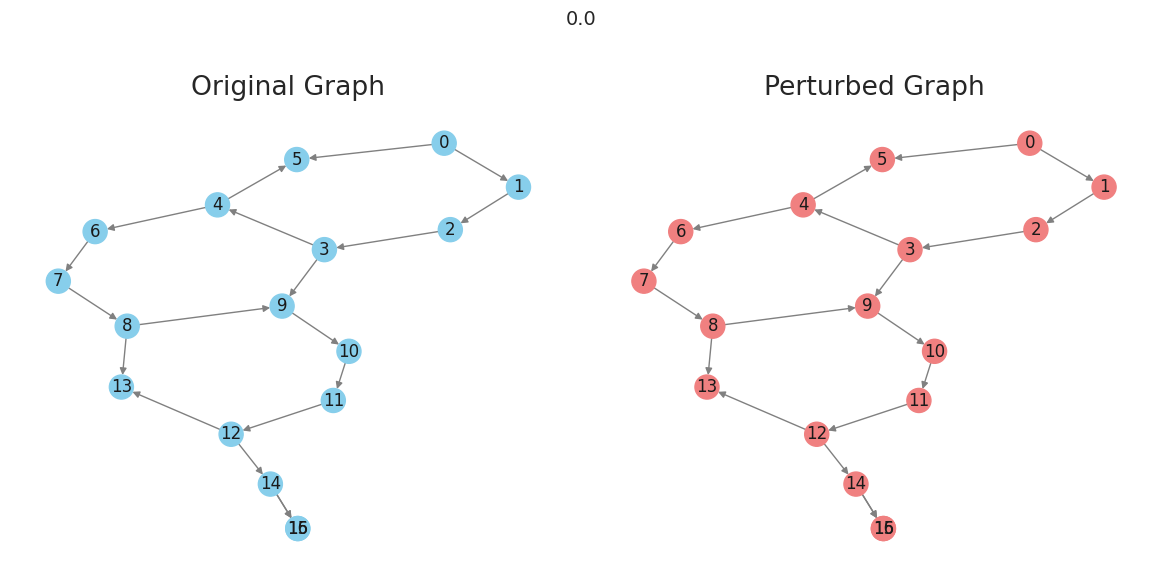

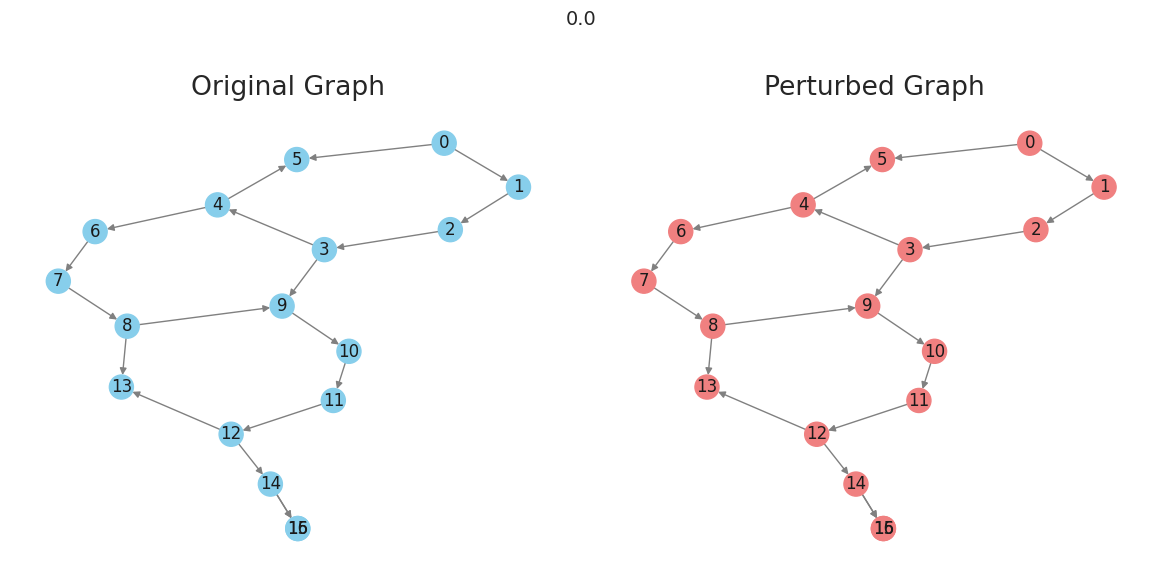

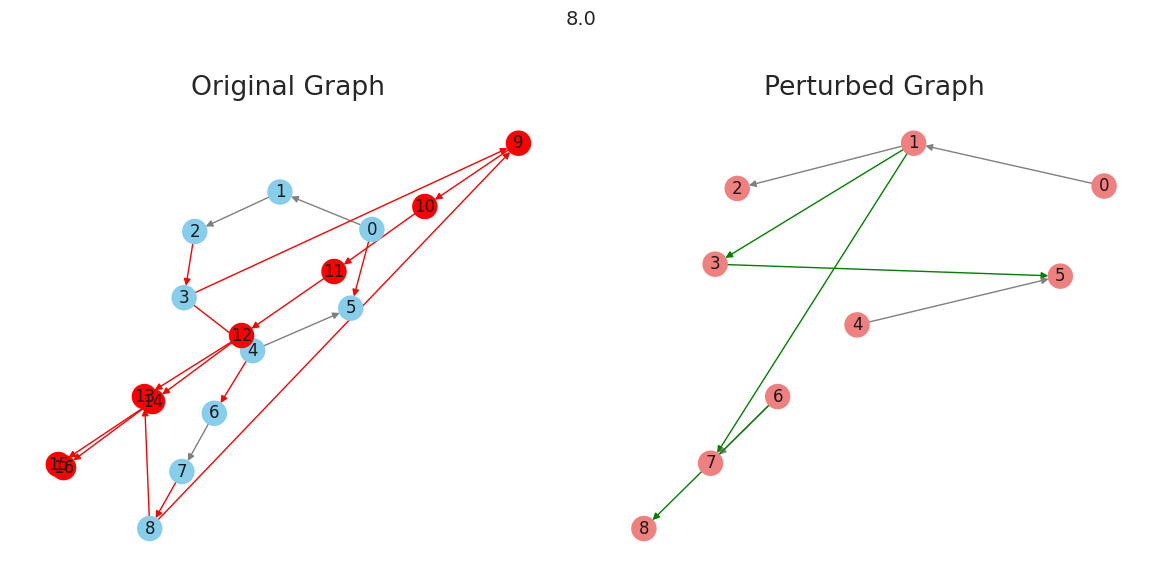

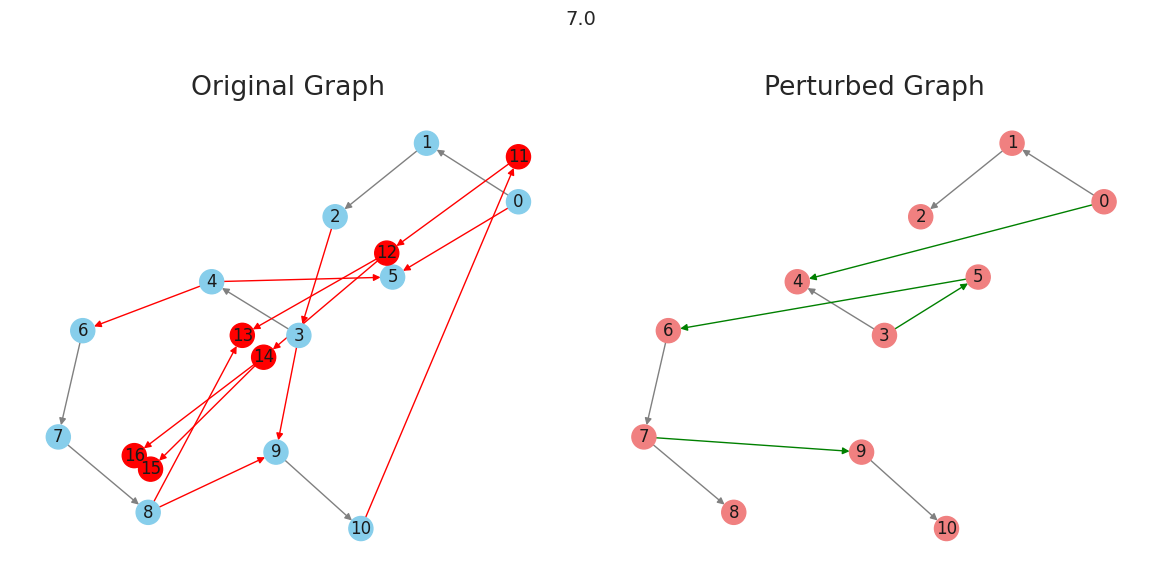

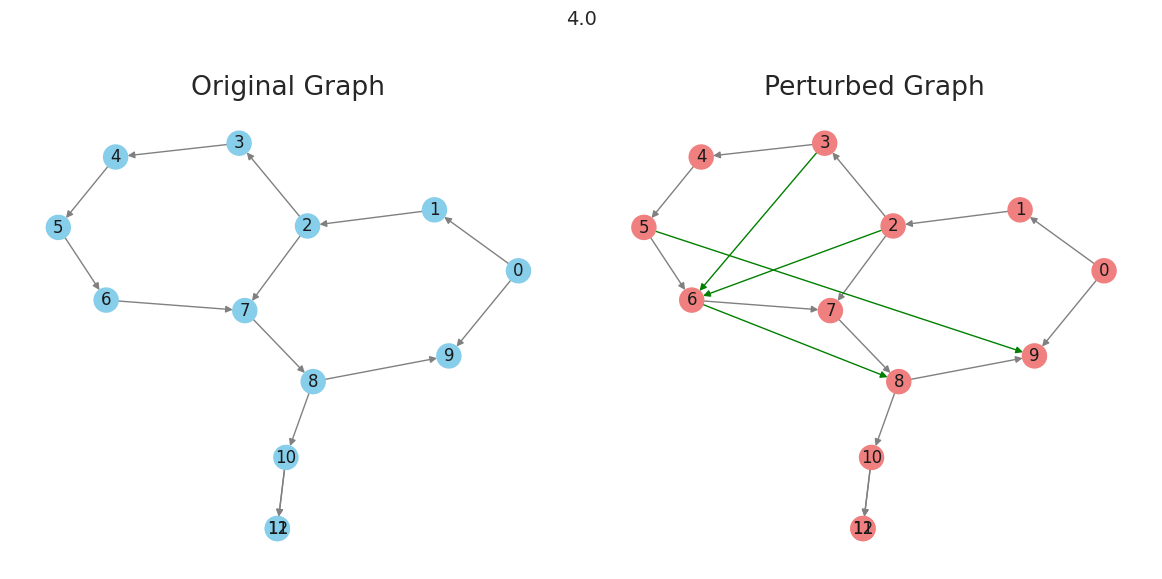

In [32]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=4,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [33]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=64, 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=25
)

Training SimGNN:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.5747 | MSE(norm): 0.5747 | MSE(raw): 323.2067 | Corr(norm): 0.0540 | Corr(raw): 0.1458
Epoch 002 | Loss: 0.1838 | MSE(norm): 0.1838 | MSE(raw): 80.6578 | Corr(norm): 0.1758 | Corr(raw): 0.5223
Epoch 003 | Loss: 0.1707 | MSE(norm): 0.1707 | MSE(raw): 73.1675 | Corr(norm): 0.1872 | Corr(raw): 0.5530
Epoch 004 | Loss: 0.1510 | MSE(norm): 0.1510 | MSE(raw): 66.3141 | Corr(norm): 0.2542 | Corr(raw): 0.5921
Epoch 005 | Loss: 0.1546 | MSE(norm): 0.1546 | MSE(raw): 67.9515 | Corr(norm): 0.2308 | Corr(raw): 0.5707
Epoch 006 | Loss: 0.1342 | MSE(norm): 0.1342 | MSE(raw): 59.6749 | Corr(norm): 0.2932 | Corr(raw): 0.6057
Epoch 007 | Loss: 0.1264 | MSE(norm): 0.1264 | MSE(raw): 54.4065 | Corr(norm): 0.3264 | Corr(raw): 0.6407
Epoch 008 | Loss: 0.1210 | MSE(norm): 0.1210 | MSE(raw): 54.6194 | Corr(norm): 0.3772 | Corr(raw): 0.6586
Epoch 009 | Loss: 0.1172 | MSE(norm): 0.1172 | MSE(raw): 50.3363 | Corr(norm): 0.3664 | Corr(raw): 0.6668
Epoch 010 | Loss: 0.1112 | MSE(norm): 0.1112 

# Distances

In [43]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import neural_approx_ged_dist

nn_GED = neural_approx_ged_dist(
    data, model
)

# Generator

In [47]:
def train_generator(cls_idx, data):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=1),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
            dict(key="cont_data", criterion=nn_GED, weight=1), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
    )

    trainer.train(
        iterations=200,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

  0%|          | 0/200 [00:00<?, ?it/s]

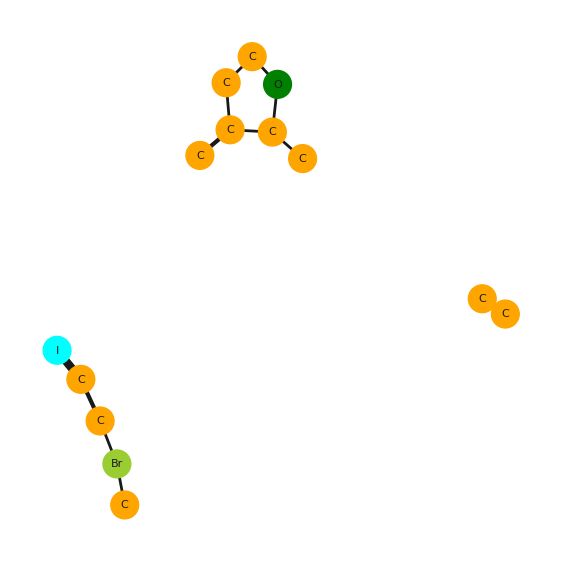

In [ ]:
import new_src.utils
from new_src.utils import plot_graph
importlib.reload(new_src.utils)

sample = train_generator(1, data), 
plot_graph(sample[0], data)

# Evaluation